In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

In [2]:
def analyze_tracks_no_gt(tracks, class_name="player"):
    frames = tracks[class_name]
    T = len(frames)
    id_frames, id_teams, id_colors, id_bboxes, id_conf, id_bbox_sizes = defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), 
    
    for t, frame_dict in enumerate(frames):
        for tid, info in frame_dict.items():
            id_frames[tid].append(t)
            id_teams[tid].append(info['team']), id_colors[tid].append(info['shirt_color']), id_bboxes[tid].append(info['bbox']), id_conf[tid].append(info['confidence']), id_bbox_sizes[tid].append(info['bbox_size'])
    
    # Metrics per id
    metrics = {}
    metrics_list = {}
    num_tracks = 0
    for tid, frames_seen in id_frames.items():
        
        if int(tid) > num_tracks:    num_tracks = int(tid)
        
        frames_seen_sorted = sorted(frames_seen)
        total_seen = len(frames_seen_sorted)
        coverage = total_seen / T

        gap_lengths = []
        movimiento_x = []
        movimiento_y = []
        prev = frames_seen_sorted[0]
        bbox_prev = id_bboxes[tid][0]
        for n_frame, f in enumerate(frames_seen_sorted[1:]):
            frame_gap = f - prev - 1
            if f != prev +1 :
                gap_lengths.append(frame_gap)

            bbox_current = id_bboxes[tid][n_frame]
            x1, y1, _, _ = bbox_current
            x1_prev, y1_prev, _, _ = bbox_prev

            dx, dy = (x1 - x1_prev) / (frame_gap+1), (y1 - y1_prev) / (frame_gap+1)

            movimiento_x.append(dx),  movimiento_y.append(dy)

            prev = f
            bbox_prev = bbox_current

        gaps = len(gap_lengths)
        mean_gap_len = np.mean(gap_lengths) if gap_lengths else 0.0
        speed = np.sqrt(np.array(movimiento_x)**2 + np.array(movimiento_y)**2) if movimiento_x else 0.0
        mean_speed = np.mean(np.sqrt(np.array(movimiento_x)**2 + np.array(movimiento_y)**2)) if movimiento_x else 0.0
        max_speed = np.max(np.sqrt(np.array(movimiento_x)**2 + np.array(movimiento_y)**2)) if movimiento_x else 0.0
        
        # team stability
        teams = id_teams.get(tid, [])
        team_mode = None
        flip_rate_static, flip_rate_dynamic, entropy = 0.0, 0.0, 0.0
        if teams:
            c = Counter(teams)
            team_mode, _ = c.most_common(1)[0]
            flips_static = sum(1 for x in teams if x != team_mode)
            flips_dynamic_bool = [teams[i] != teams[i - 1] for i in range(1, len(teams))]
            flips_dynamic = sum(teams[i] != teams[i - 1] for i in range(1, len(teams)))
            flip_rate_static = flips_static / len(teams) if teams else None
            flip_rate_dynamic = flips_dynamic / (len(teams) - 1) if len(teams) > 1 else None

            # entropy
            ps = np.array(list(c.values()))/sum(c.values())
            entropy = -np.sum(ps * np.log2(ps + 1e-12))
        
        # color variance (if numeric)
        colors = np.array(id_colors.get(tid, []), dtype=float) if id_colors.get(tid) else None
        color_var = float(np.mean(np.var(colors, axis=0))) if colors is not None and len(colors)>0 else None
        color_diff = float(np.mean(np.linalg.norm(np.diff(colors, axis=0), axis=1))) if colors is not None and len(colors)>0 else None
        
        # bbox size var
        sizes = np.array(id_bbox_sizes.get(tid, []), dtype=float) if id_bbox_sizes.get(tid) else None
        size_cv = (np.std(sizes)/np.mean(sizes)) if sizes is not None and len(sizes)>1 else None
        
        metrics_list[tid] = {
            "frames_seen": frames_seen_sorted, "speed": speed, "flips": flips_dynamic_bool, "bbox_size": sizes, "confs": id_conf[tid]
        }
        
        metrics[tid] = {
            "coverage": coverage, "total_seen": total_seen, "fragments": gaps, "mean_gap_len": mean_gap_len, "mean_speed": mean_speed, "max_speed": max_speed,
            "team_mode": team_mode, "team_flip_rate_static": flip_rate_static, "team_flip_rate_dynamic": flip_rate_dynamic, "team_entropy": entropy,
            "color_var": color_var, "color_diff": color_diff, "bbox_size_cv": size_cv, "mean_confidence": float(np.mean(id_conf[tid])) if id_conf.get(tid) else None
        }
    # Summary stats
    covs = [m["coverage"] for m in metrics.values()]
    total_seen = [m["total_seen"] for m in metrics.values()]
    frag = [m["fragments"] for m in metrics.values()]
    mean_gap_len = [m["mean_gap_len"] for m in metrics.values()]
    mean_speed = [m["mean_speed"] for m in metrics.values()]
    max_speed = [m["max_speed"] for m in metrics.values()]
    flip_rates_static  = [m["team_flip_rate_static" ] for m in metrics.values() if m["team_flip_rate_static"] is not None]
    flip_rates_dynamic = [m["team_flip_rate_dynamic"] for m in metrics.values() if m["team_flip_rate_dynamic"] is not None]
    entropy = [m["team_entropy"] for m in metrics.values()]
    color_var = [m["color_var"] for m in metrics.values()]
    color_diff = [m["color_diff"] for m in metrics.values()]
    bbox_size = [m["bbox_size_cv"] for m in metrics.values() if m["bbox_size_cv"] is not None]
    confidence = [m["mean_confidence"] for m in metrics.values() if m["mean_confidence"] is not None]

    summary = {
        "n_tracks": num_tracks,
        "num_tracks": len(metrics),

        "mean_coverage": float(np.mean(covs)) if covs else 0.0, "median_coverage": float(np.median(covs)) if covs else 0.0, "25_coverage": float(np.quantile(covs, 0.25)) if covs else 0.0,
        "mean_fragments": float(np.mean(frag)) if frag else 0.0, "median_fragments": float(np.median(frag)) if frag else 0.0, "mean_gap_len_mean": float(np.mean(mean_gap_len)) if mean_gap_len else 0.0, "median_gap_len_mean": float(np.median(mean_gap_len)) if mean_gap_len else 0.0, 
        
        "pct_tracks_with_fragments": float(np.mean([1 if f>0 else 0 for f in frag])) if frag else 0.0,

        "mean_speed": float(np.mean(mean_speed) if mean_speed else 0.0),
        "max_speed": float(np.mean(max_speed) if max_speed else 0.0),
        
        "mean_team_flip_rate": float(np.mean(flip_rates_static)) if flip_rates_static else 0.0,
        "mean_team_flip_dynamic": float(np.mean(flip_rates_dynamic)) if flip_rates_dynamic else 0.0,
        "entropy": float(np.mean(entropy)) if entropy else 0.0,
        "color_var": float(np.mean(color_var)) if color_var else 0.0,
        "color_diff": float(np.mean(color_diff)) if color_diff else 0.0,
        "bbox_size": float(np.mean(bbox_size)) if bbox_size else 0.0,
        "confidence": float(np.mean(confidence)) if confidence else 0.0,
    }
    return metrics, metrics_list, summary, T

In [3]:
with open("./tracks_m.json", "r", encoding="utf-8") as f:
    tracks = json.load(f)

In [4]:
metrics, metrics_list, summary, T = analyze_tracks_no_gt(tracks)
df_metrics = pd.DataFrame(metrics).T
df_metrics.head()

c:\Users\hecto\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\hecto\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,coverage,total_seen,fragments,mean_gap_len,mean_speed,max_speed,team_mode,team_flip_rate_static,team_flip_rate_dynamic,team_entropy,color_var,color_diff,bbox_size_cv,mean_confidence
1,0.985333,739,3,2.666667,3.351926,19.197349,Wolfsburgo,0.041949,0.056911,0.251156,188.696447,8.814318,0.384065,0.816802
2,0.265333,199,0,0.0,3.333865,14.544967,Wolfsburgo,0.125628,0.161616,0.545325,514.278095,21.98056,0.35929,0.784816
3,0.489333,367,3,5.666667,2.626785,11.338956,Real Madrid,0.057221,0.084699,0.316312,301.420307,14.159381,0.400185,0.772192
4,0.989333,742,2,2.5,2.903289,22.018951,Wolfsburgo,0.03504,0.043185,0.219071,144.720468,6.812007,0.446017,0.833872
5,0.961333,721,9,2.888889,3.295886,32.388047,Real Madrid,0.012483,0.022222,0.096835,94.824557,5.229565,0.407352,0.82864


In [5]:
df_metrics_list = pd.DataFrame(metrics_list).T
df_metrics_list.head()

,frames_seen,speed,flips,bbox_size,confs
1,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...","[0.0, 2.9118244946776186, 2.894020913479149, 2...","[False, False, False, False, False, False, Fal...","[7623.0, 6930.0, 6636.0, 6468.0, 7488.0, 8658....","[0.8828758597373962, 0.8714739680290222, 0.862..."
2,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...","[0.0, 3.7259385893217907, 7.68931049377422, 14...","[False, False, True, True, False, False, False...","[9522.0, 9108.0, 8568.0, 2640.0, 7668.0, 10767...","[0.8268886804580688, 0.7180036306381226, 0.822..."
3,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...","[0.0, 3.2960924105608727, 3.7661895452429044, ...","[False, False, False, False, True, True, False...","[8103.0, 7446.0, 6624.0, 6390.0, 6090.0, 8541....","[0.8386741280555725, 0.8458430767059326, 0.839..."
4,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...","[0.0, 8.203077135400546, 7.875442475658665, 4....","[False, False, False, False, True, True, False...","[8712.0, 8712.0, 8352.0, 10692.0, 10767.0, 660...","[0.7975446581840515, 0.8421707153320312, 0.846..."
5,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...","[0.0, 3.2084085251952685, 3.314039709218753, 1...","[False, False, True, False, True, False, False...","[11448.0, 11340.0, 11544.0, 11172.0, 5538.0, 1...","[0.8557016253471375, 0.8674798011779785, 0.872..."


<Axes: >

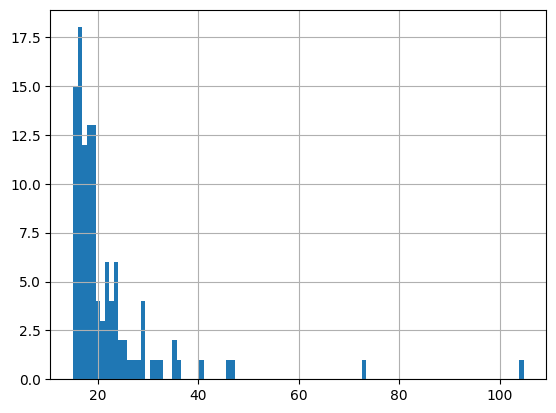

In [6]:
aux = df_metrics_list["speed"].explode()
aux[aux>15].hist(bins=100)

1328


<Axes: >

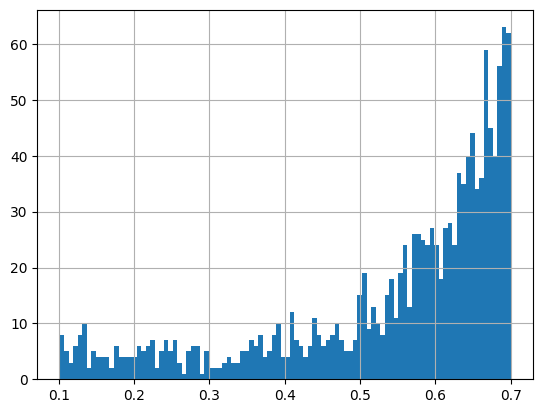

In [7]:
aux = df_metrics_list["confs"].explode()
print(len(aux[aux<0.7]))
aux[aux<0.7].hist(bins=100)

In [25]:
df_metrics_list["mean_coverage"] = df_metrics_list["frames_seen"].str.len() / T

<Axes: >

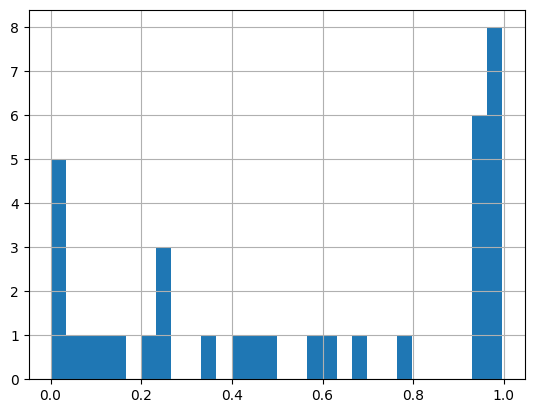

In [28]:
df_metrics_list["mean_coverage"].hist(bins=30)

In [30]:
aux = df_metrics_list[df_metrics_list["mean_coverage"] < 0.8]

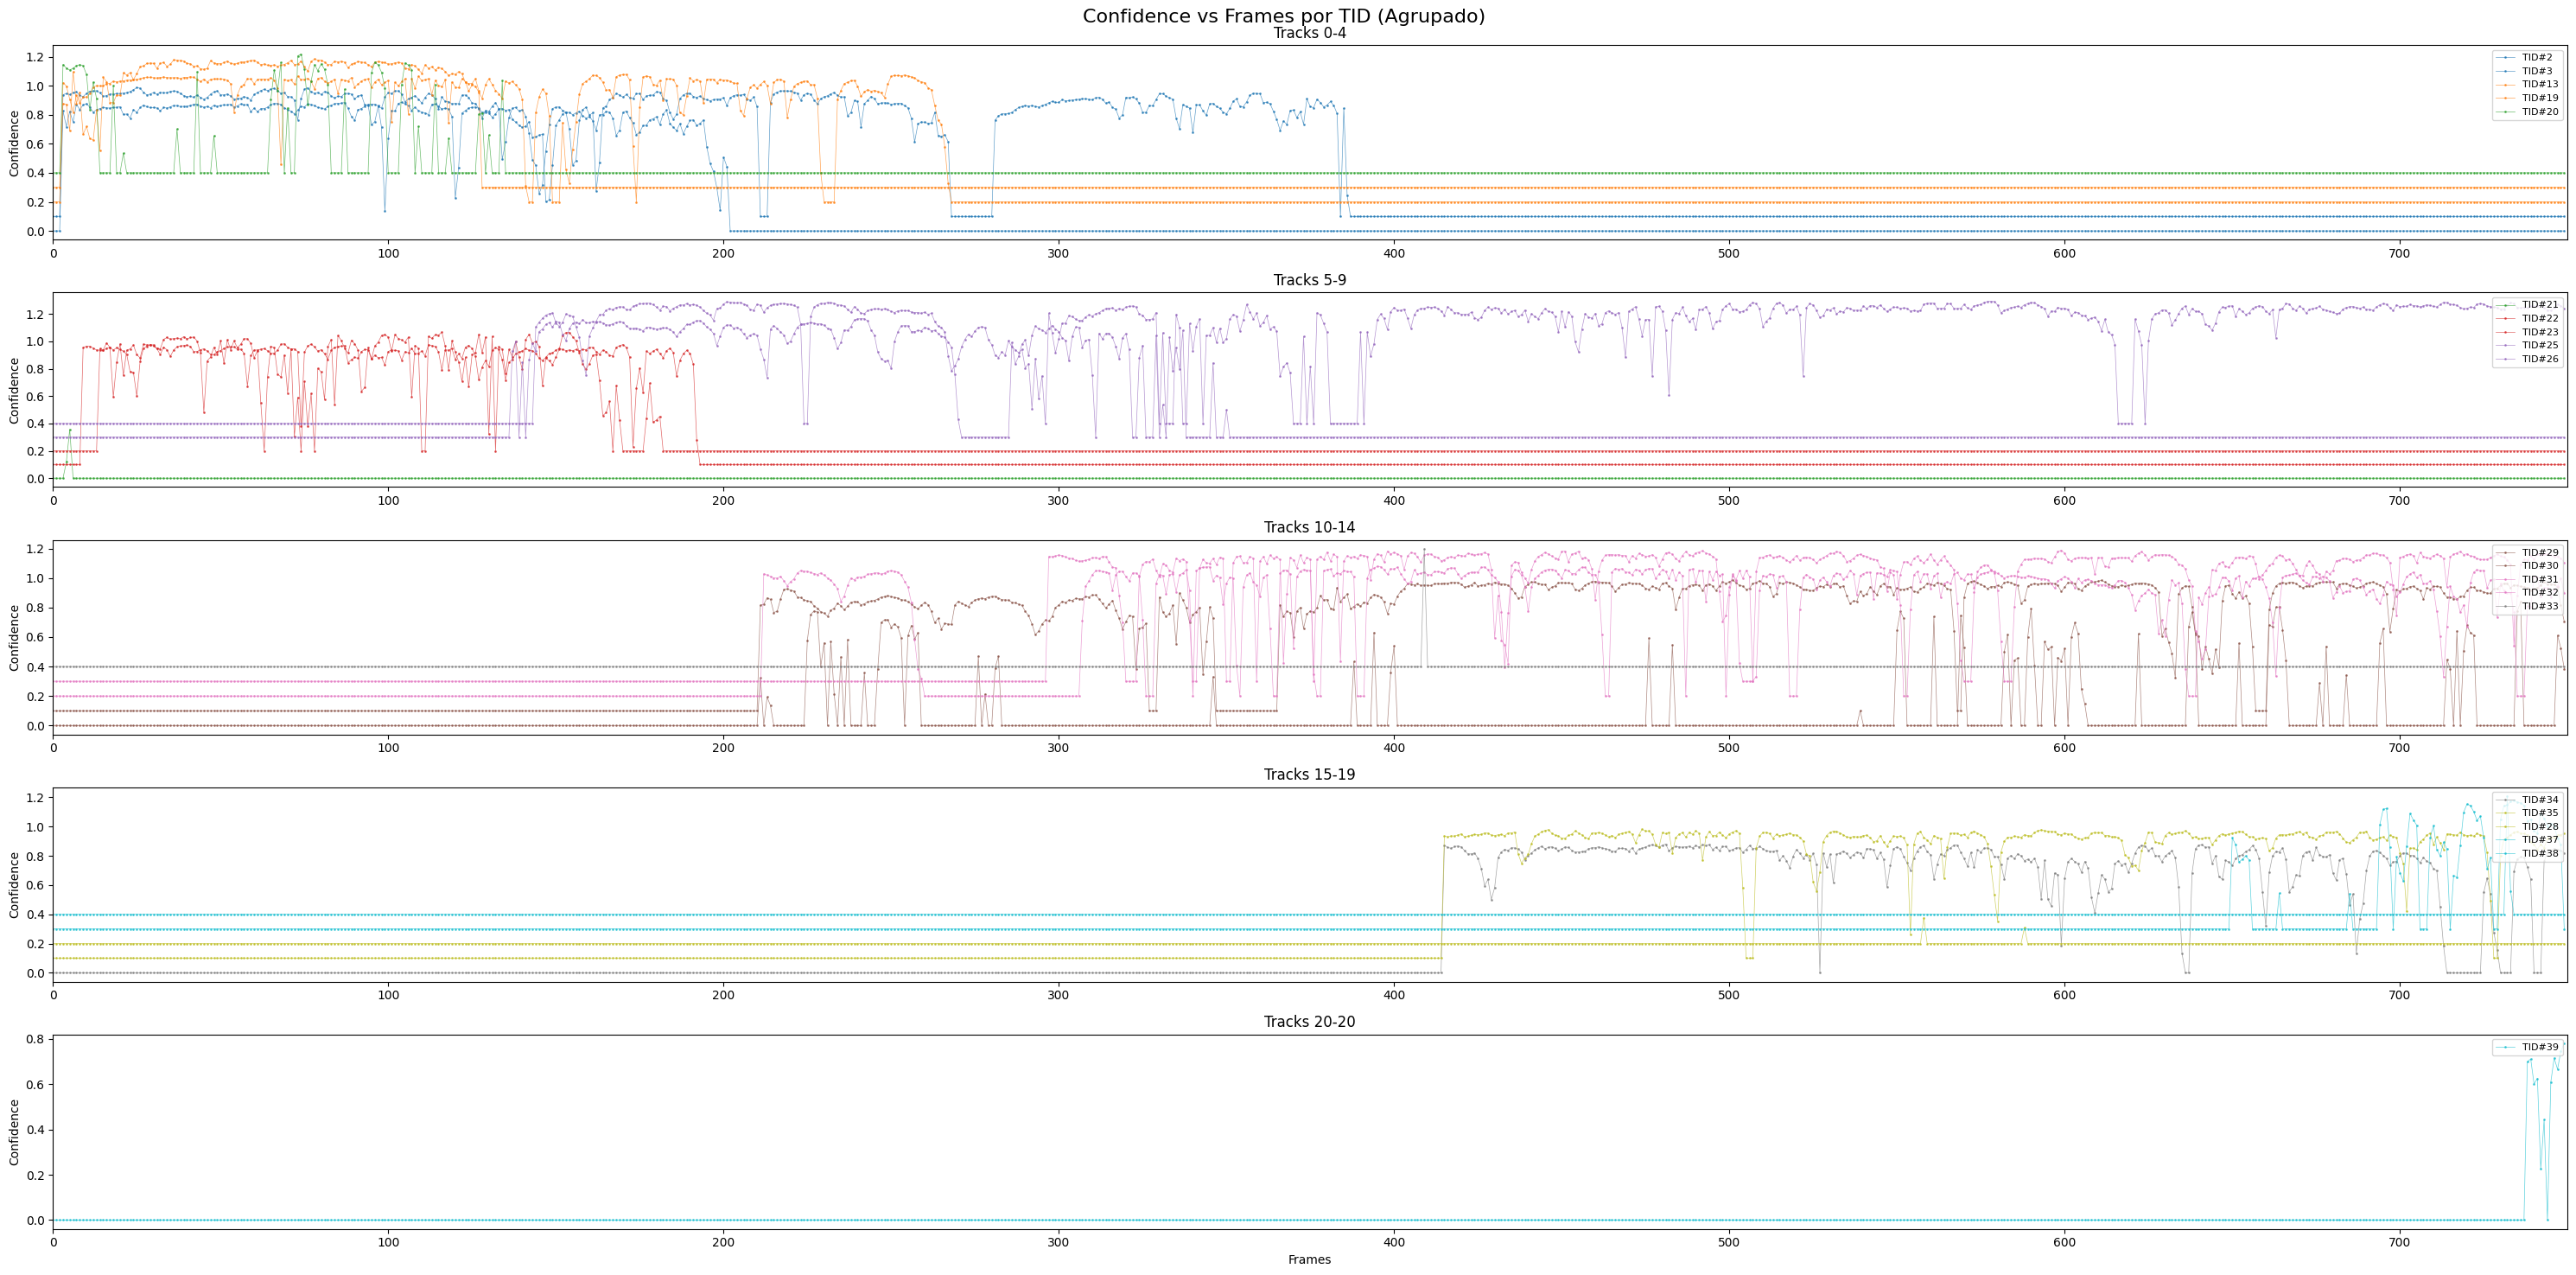

In [36]:
# Calcular cuántos tracks por fila
tracks_per_row = 5
num_rows = math.ceil(len(aux) / tracks_per_row)

fig, axes = plt.subplots(num_rows, 1, figsize=(30, 3 * num_rows))
if num_rows == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Colores distintos para cada TID
colors = plt.cm.tab10(np.linspace(0, 1, len(aux)))

for row_idx, ax in enumerate(axes):
    start_tid_idx = row_idx * tracks_per_row
    end_tid_idx = min((row_idx + 1) * tracks_per_row, len(aux))
    
    tids_in_row = aux.index[start_tid_idx:end_tid_idx]
    
    for i, tid in enumerate(tids_in_row):
        row = aux.loc[tid]
        frames_seen = row["frames_seen"]
        confidences = row["confs"]
        
        # Crear array completo con 0 para frames no vistos
        y_full = np.zeros(T)
        for frame, conf in zip(frames_seen, confidences):
            if frame < T:
                y_full[frame] = conf
        
        # Plot con offset vertical para separar tracks
        vertical_offset = i * 0.1  # Ajusta este valor según necesites
        ax.plot(range(T), y_full + vertical_offset, 
                color=colors[start_tid_idx + i], 
                label=f"TID#{tid}", marker='o', markersize=1, alpha=0.7, linewidth=0.5)
    
    ax.set_ylabel("Confidence")
    ax.set_xlim(0, T)
    ax.legend(loc='upper right', fontsize=8)
    if row_idx == num_rows - 1:
        ax.set_xlabel("Frames")
    ax.set_title(f"Tracks {start_tid_idx}-{end_tid_idx-1}")

plt.suptitle("Confidence vs Frames por TID (Agrupado)", fontsize=16)
plt.tight_layout()
plt.show()